# Импорты

In [ ]:
!pip install -q facenet-pytorch --no-deps

In [ ]:
from pathlib import Path
from typing import Union

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b0

from facenet_pytorch import MTCNN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка весов

In [ ]:
PROJECT_DIR = Path("/content/celeba")

# из ноутбука Face Alignment
HOURGLASS_WEIGHTS = PROJECT_DIR / "stacked_hourglass_best.pt"

# из ArcFace
RECOGNITION_WEIGHTS = PROJECT_DIR / "arcface_efficientnet_b0_best.pt"

# Функция для чтения файла с весами моделей

Добавила для удобства функцию:

In [ ]:
def load_checkpoint(path: Union[str, Path], device):
    path = Path(path)

    checkpoint = torch.load(path, map_location=device, weights_only=True)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]

    return checkpoint

# Функция перевода heatmaps в координаты

In [ ]:
def heatmaps_to_points(heatmaps, image_size=128):
    """
    heatmaps: torch.Tensor [B, K, H, W]
    return: torch.Tensor [B, K, 2] в координатах image_size x image_size
    """
    b, k, h, w = heatmaps.shape

    flat = heatmaps.reshape(b, k, -1) # развернула в [B, K, H * W]
    idx = flat.argmax(dim=-1) # позиция, где максимум

    ys = idx // w
    xs = idx % w

    points = torch.stack([xs, ys], dim=-1).float()

    # масштабирую в координаты image_size * image_size
    points[..., 0] *= image_size / w
    points[..., 1] *= image_size / h

    return points

# Функция выравнивания

Использую афинное преобразование

In [ ]:
def get_arcface_reference_points(output_size=128):
    """
    стандартные reference-точки ArcFace для размера 112x112,
    масштабированные под output_size
    """
    ref_112 = np.array([
        [38.2946, 51.6963],
        [73.5318, 51.5014],
        [56.0252, 71.7366],
        [41.5493, 92.3655],
        [70.7299, 92.2041],
    ], dtype=np.float32)

    return ref_112 * (output_size / 112.0)

In [ ]:
def align_face_by_points(img_np, src_points, output_size=128):
    """
    img_np - фото в виде массива numpy
    src_points - найденные landmarks
    """
    src_points = np.asarray(src_points, dtype=np.float32)
    dst_points = get_arcface_reference_points(output_size=output_size)

    # ищу матрицу перехода для афинного преобразования
    matrix, _ = cv2.estimateAffinePartial2D(
        src_points,
        dst_points,
        method=cv2.LMEDS,
    )

    if matrix is None:
        return None

    # применяю преобразование
    aligned = cv2.warpAffine(
        img_np,
        matrix,
        (output_size, output_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )

    return aligned

# **Архитектура Stacked Hourglass**

## ResidualBlock

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.skip = (nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1))

        mid_channels = out_channels // 2

        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, out_channels, kernel_size=1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))

        return self.relu(x + residual)

## HourglassBlock

In [ ]:
class HourglassBlock(nn.Module):
    def __init__(self, depth, num_features):
        super().__init__()
        self.depth = depth

        self.up1 = ResidualBlock(num_features, num_features)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1 = ResidualBlock(num_features, num_features)

        if depth > 1:
            self.low2 = HourglassBlock(depth - 1, num_features)
        else:
            self.low2 = ResidualBlock(num_features, num_features)

        self.low3 = ResidualBlock(num_features, num_features)

        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

    def forward(self, x):
        up1 = self.up1(x)

        low = self.pool(x)
        low = self.low1(low)
        low = self.low2(low)
        low = self.low3(low)

        up2 = self.upsample(low)

        return up1 + up2

## StackedHourglass

In [ ]:
class StackedHourglass(nn.Module):
    def __init__(self, num_landmarks=5, num_stacks=2, num_features=128, depth=3):
        super().__init__()

        self.num_stacks = num_stacks

        # 128x128 в 64x64
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64, 128),
            ResidualBlock(128, num_features),
        )

        self.hourglasses = nn.ModuleList([
            HourglassBlock(depth=depth, num_features=num_features)
            for _ in range(num_stacks)
        ])

        self.features = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(num_features, num_features),
                nn.Conv2d(num_features, num_features, kernel_size=1),
                nn.BatchNorm2d(num_features),
                nn.ReLU(inplace=True),
            )
            for _ in range(num_stacks)
        ])

        self.preds = nn.ModuleList([
            nn.Conv2d(num_features, num_landmarks, kernel_size=1)
            for _ in range(num_stacks)
        ])

        self.merge_features = nn.ModuleList([
            nn.Conv2d(num_features, num_features, kernel_size=1)
            for _ in range(num_stacks - 1)
        ])

        self.merge_preds = nn.ModuleList([
            nn.Conv2d(num_landmarks, num_features, kernel_size=1)
            for _ in range(num_stacks - 1)
        ])

    def forward(self, x):
        x = self.pre(x)

        outputs = []

        for i in range(self.num_stacks):
            y = self.hourglasses[i](x)
            y = self.features[i](y)
            pred = self.preds[i](y)
            outputs.append(pred)

            if i < self.num_stacks - 1:
                x = x + self.merge_features[i](y) + self.merge_preds[i](pred)

        return outputs

## Загрузка модели !!!

In [ ]:
landmark_model = StackedHourglass(
    num_landmarks=5,
    num_stacks=2,
    num_features=128,
    depth=3,
).to(device)

In [ ]:
landmark_state = load_checkpoint(HOURGLASS_WEIGHTS, device)
landmark_model.load_state_dict(landmark_state, strict=True)
landmark_model.eval()

StackedHourglass(
  (pre): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ResidualBlock(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (4): ResidualBlock(
      (skip): Identity()
      (conv1): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e

# **Модель эмбеддингов EfficientNet-B0**

In [ ]:
class EfficientNetEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()

        # weights=None потому что дальше загружаются мои обученные веса.
        backbone = efficientnet_b0(weights=None)

        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.embedding = nn.Sequential(
            nn.Linear(in_features, embedding_dim, bias=False),
            nn.BatchNorm1d(embedding_dim),
            nn.Dropout(p=0.3),
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.embedding(x)

In [ ]:
recognition_model = EfficientNetEmbeddingModel(
    embedding_dim=512,
).to(device)

In [ ]:
full_arcface_state = load_checkpoint(RECOGNITION_WEIGHTS, device)

In [ ]:
embedding_prefix = "embedding_model."

embedding_state = {
    key[len(embedding_prefix):]: value
    for key, value in full_arcface_state.items()
    if key.startswith(embedding_prefix)
}

In [ ]:
recognition_model.load_state_dict(embedding_state, strict=True)
recognition_model.eval()

EfficientNetEmbeddingModel(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
      

In [ ]:
recognition_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# **Готовый детектор**

`MTCNN` использую только для получения bounding boxes.  
Возвращаемые им готовые facial landmarks не запрашиваются и не используются.

In [ ]:
face_detector = MTCNN(
    keep_all=True,
    min_face_size=40,
    thresholds=[0.6, 0.7, 0.7],
    device=device,
)

# **Пайплайн**

In [ ]:
ImageInput = Union[str, Path, Image.Image, np.ndarray]

In [ ]:
class FullFaceRecognitionPipeline:
    def __init__(
        self,
        detector,
        landmark_model,
        recognition_model,
        device,
        detection_threshold=0.90,
        crop_margin=0.0,
        landmark_image_size=128,
    ):
        self.detector = detector
        self.landmark_model = landmark_model
        self.recognition_model = recognition_model
        self.device = device
        self.detection_threshold = detection_threshold
        self.crop_margin = crop_margin
        self.landmark_image_size = landmark_image_size

    def crop_face(self, image_np, box):
        image_h, image_w = image_np.shape[:2]
        x1, y1, x2, y2 = map(float, box)

        box_w = x2 - x1
        box_h = y2 - y1

        x1 -= box_w * self.crop_margin
        x2 += box_w * self.crop_margin
        y1 -= box_h * self.crop_margin
        y2 += box_h * self.crop_margin

        x1 = max(0, int(np.floor(x1)))
        y1 = max(0, int(np.floor(y1)))
        x2 = min(image_w, int(np.ceil(x2)))
        y2 = min(image_h, int(np.ceil(y2)))

        crop = image_np[y1:y2, x1:x2]

        crop_resized = cv2.resize(
            crop,
            (self.landmark_image_size, self.landmark_image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        return crop_resized, (x1, y1, x2, y2)

    @torch.inference_mode()
    def predict_landmarks(self, crop):
        image = crop.astype(np.float32) / 255.0
        tensor = torch.from_numpy(image).permute(2, 0, 1)

        tensor = (tensor - 0.5) / 0.5
        tensor = tensor.unsqueeze(0).to(self.device)

        pred_heatmaps = self.landmark_model(tensor)[-1]

        points = heatmaps_to_points(
            pred_heatmaps,
            image_size=self.landmark_image_size,
        )[0]

        return points.cpu().numpy()

    @torch.inference_mode()
    def extract_embedding(self, aligned_face):
        pil_face = Image.fromarray(aligned_face.astype(np.uint8))
        tensor = recognition_transform(pil_face)
        tensor = tensor.unsqueeze(0).to(self.device)

        embedding = self.recognition_model(tensor)
        embedding = F.normalize(embedding, p=2, dim=1)

        return embedding[0].cpu()

    @staticmethod
    def landmarks_to_original(points, bbox, crop_size=128):
        x1, y1, x2, y2 = bbox

        width = x2 - x1
        height = y2 - y1

        points = np.asarray(points, dtype=np.float32).copy()

        points[:, 0] = x1 + points[:, 0] * width / crop_size
        points[:, 1] = y1 + points[:, 1] * height / crop_size

        return points

    def __call__(self, image: ImageInput):
        pil_image = Image.open(image).convert("RGB")
        image_np = np.array(pil_image)

        boxes, probabilities = self.detector.detect(pil_image)

        if boxes is None or probabilities is None:
            return []

        results = []

        for box, probability in zip(boxes, probabilities):
            probability = float(probability)

            if probability < self.detection_threshold:
                continue

            crop, clipped_box = self.crop_face(image_np, box)

            landmarks_crop = self.predict_landmarks(crop)

            aligned_face = align_face_by_points(
                crop,
                landmarks_crop,
                output_size=self.landmark_image_size,
            )

            if aligned_face is None:
                continue

            embedding = self.extract_embedding(aligned_face)

            landmarks_original = self.landmarks_to_original(
                landmarks_crop,
                clipped_box,
                crop_size=self.landmark_image_size,
            )

            results.append({
                "bbox": clipped_box,
                "detection_probability": probability,
                "crop": crop,
                "landmarks_crop": landmarks_crop,
                "landmarks_original": landmarks_original,
                "aligned_face": aligned_face,
                "embedding": embedding,
            })

        return results

In [ ]:
pipeline = FullFaceRecognitionPipeline(
    detector=face_detector,
    landmark_model=landmark_model,
    recognition_model=recognition_model,
    device=device,
    detection_threshold=0.90,
    crop_margin=0.0,
)

# Функция для визуализации

Фугкция, чтобы красиво представить результат:

In [ ]:
def show_pipeline_result(image, results):
    pil_image = Image.open(image).convert("RGB")

    if len(results) == 0:
        plt.figure(figsize=(8, 6))
        plt.imshow(pil_image)
        plt.title("Лица не найдены")
        plt.axis("off")
        plt.show()
        return

    num_faces = len(results)
    fig, axes = plt.subplots(
        1,
        num_faces + 1,
        figsize=(5 * (num_faces + 1), 5),
    )

    axes[0].imshow(pil_image)
    axes[0].set_title(f"Исходное изображение:")

    for face_index, result in enumerate(results):
        x1, y1, x2, y2 = result["bbox"]

        rectangle = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )
        axes[0].add_patch(rectangle)

        points = result["landmarks_original"]
        axes[0].scatter(points[:, 0], points[:, 1], s=25)
        axes[0].text(
            x1,
            max(0, y1 - 5),
            f"face",
        )

        axes[face_index + 1].imshow(result["aligned_face"])
        axes[face_index + 1].set_title(f"Выровненное лицо:")
        axes[face_index + 1].axis("off")

    axes[0].axis("off")
    plt.tight_layout()
    plt.show()

# **Загрузка датасета**

Выбрала фотографии из датасета CelebA, которые отобрала в первом ноутбуке (не выровненные):

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/selected_celeba_images.zip")

In [ ]:
EXTRACT_DIR = Path("/content/celeba/selected_photo")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

!unzip -q "$ZIP_PATH" -d "$EXTRACT_DIR"

In [ ]:
IDENTITY_PATH = PROJECT_DIR / "identity_CelebA.txt"

identity_df = pd.read_csv(
    IDENTITY_PATH,
    sep=r"\s+",
    header=None,
    names=["image_id", "identity_id"],
)

In [ ]:
PHOTO_DIR = PROJECT_DIR / "selected_photo"

# **Тесты**

Найдено лиц: 1
face 1: bbox=(280, 151, 589, 563), det_prob=0.9999, embedding_shape=(512,), 


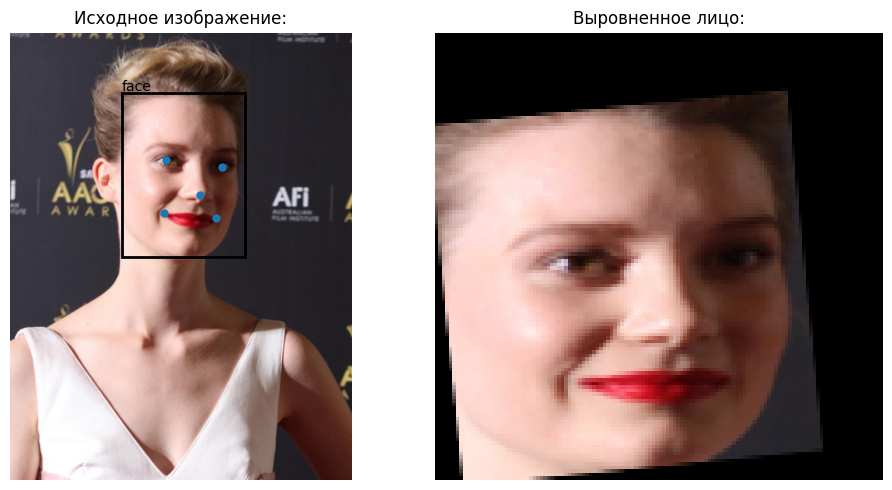

In [ ]:
test_path = "/content/celeba/selected_photo/000100.jpg"

results = pipeline(test_path)

print("Найдено лиц:", len(results))
for index, result in enumerate(results):
    print(
        f"face {index + 1}: "
        f"bbox={result['bbox']}, "
        f"det_prob={result['detection_probability']:.4f}, "
        f"embedding_shape={tuple(result['embedding'].shape)}, "
    )

show_pipeline_result(test_path, results)

Дальше решила вывести показать 5 фото относящихся к одному человеку:

identity_id: 4126
Фото: ['009122.jpg', '010765.jpg', '010971.jpg', '013744.jpg', '014783.jpg']

009122.jpg
Найдено лиц: 1


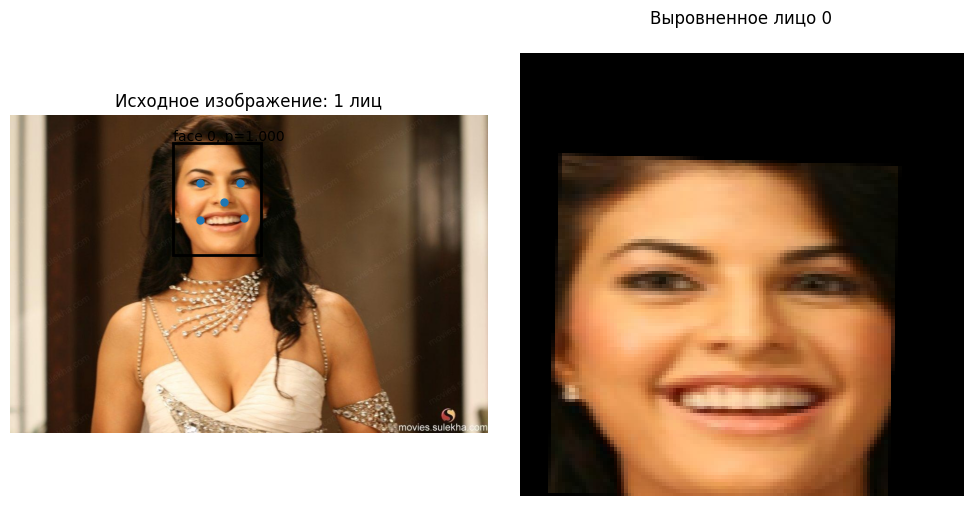


010765.jpg
Найдено лиц: 1


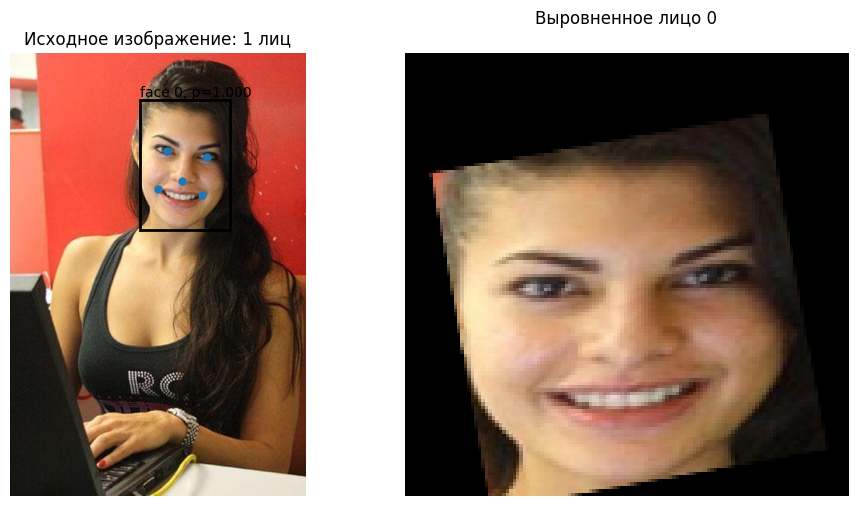


010971.jpg
Найдено лиц: 1


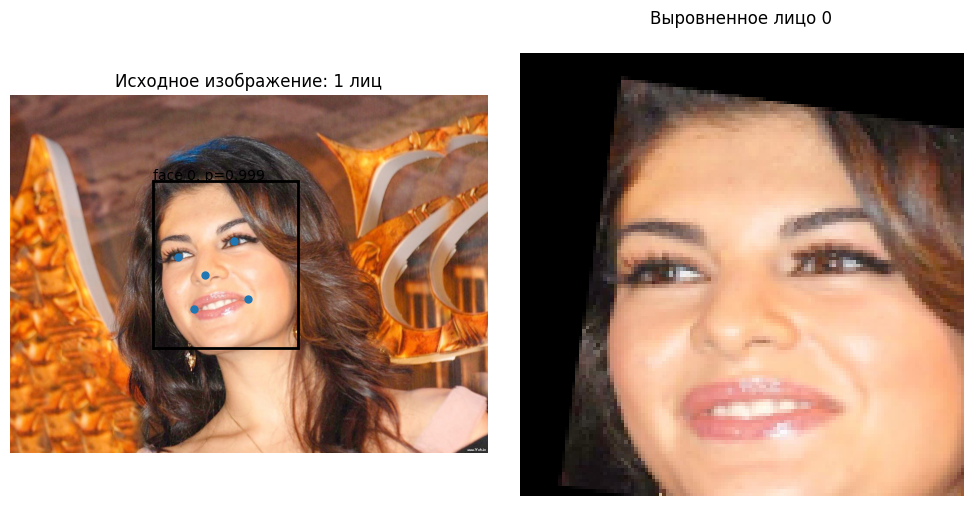


013744.jpg
Найдено лиц: 1


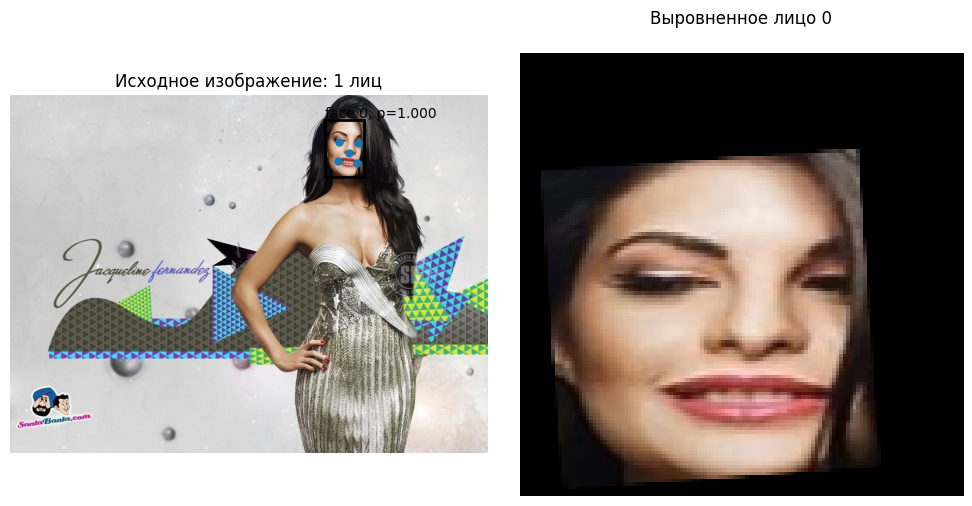


014783.jpg
Найдено лиц: 1


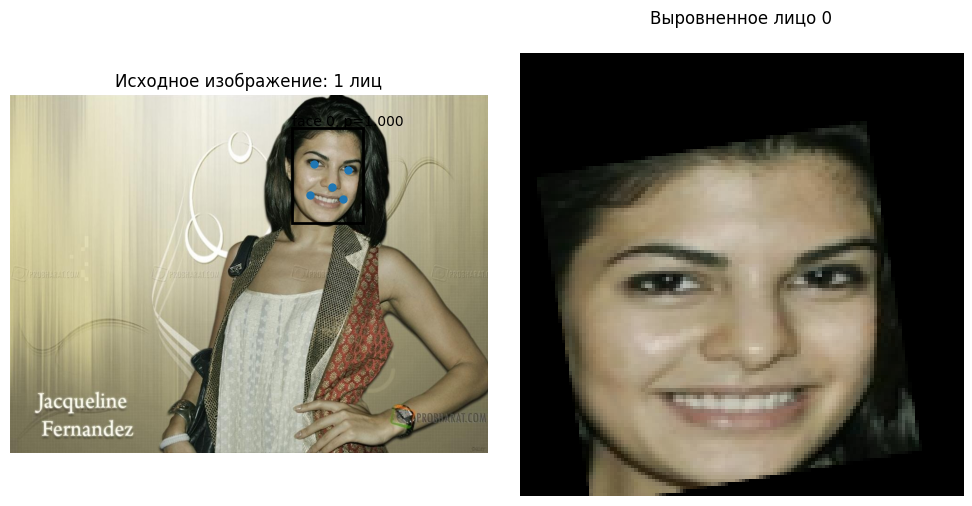

In [ ]:
photo_paths = {
    path.name: path
    for path in PHOTO_DIR.glob("*.jpg")
}

identity_df = identity_df[identity_df["image_id"].isin(photo_paths.keys())].copy()
identity_df["image_path"] = identity_df["image_id"].map(photo_paths)

counts = identity_df["identity_id"].value_counts()
person_id = counts[counts >= 5].index[5]

one_person_df = (
    identity_df[identity_df["identity_id"] == person_id]
    .head(5)
    .reset_index(drop=True)
)

print(f"identity_id: {person_id}")
print("Фото:", one_person_df["image_id"].tolist())

for _, row in one_person_df.iterrows():
    image_path = row["image_path"]

    results = pipeline(image_path)

    print(f"\n{row['image_id']}")
    print("Найдено лиц:", len(results))

    show_pipeline_result(image_path, results)

In [ ]:
PHOTO_DIR = PROJECT_DIR / "selected_photo"
IDENTITY_PATH = PROJECT_DIR / "identity_CelebA.txt"

identity_df = pd.read_csv(IDENTITY_PATH, sep=r"\s+", header=None, names=["image_id", "identity_id"])

photo_names = {path.name for path in PHOTO_DIR.glob("*.jpg")}

identity_df = identity_df[identity_df["image_id"].isin(photo_names)].copy()
identity_df["image_path"] = identity_df["image_id"].apply(lambda name: PHOTO_DIR / name)

counts = identity_df["identity_id"].value_counts()

same_person_id = counts[counts >= 5].index[0]

same_df = (
    identity_df[identity_df["identity_id"] == same_person_id]
    .head(5)
    .reset_index(drop=True)
)

different_df = (
    identity_df[identity_df["identity_id"] != same_person_id]
    .drop_duplicates("identity_id")
    .head(5)
    .reset_index(drop=True)
)

print("Один человек identity_id:", same_person_id)
print("Фото одного человека:", same_df["image_id"].tolist())
print("Фото разных людей:", different_df["image_id"].tolist())

Один человек identity_id: 3782
Фото одного человека: ['162911.jpg', '162999.jpg', '163029.jpg', '165037.jpg', '168682.jpg']
Фото разных людей: ['000001.jpg', '000002.jpg', '000015.jpg', '000018.jpg', '000088.jpg']


In [ ]:
same_similarities = []
same_pair_labels = []

for i in range(len(same_embeddings)):
    for j in range(i + 1, len(same_embeddings)):
        sim = F.cosine_similarity(
            same_embeddings[i].unsqueeze(0),
            same_embeddings[j].unsqueeze(0),
        ).item()

        same_similarities.append(sim)
        same_pair_labels.append(f"{same_names[i]} vs {same_names[j]}")


# Собираю similarity: первое фото человека против фото других людей
different_similarities = []
different_pair_labels = []

anchor_embedding = same_embeddings[0]
anchor_name = same_names[0]

for i, embedding in enumerate(different_embeddings):
    sim = F.cosine_similarity(
        anchor_embedding.unsqueeze(0),
        embedding.unsqueeze(0),
    ).item()

    different_similarities.append(sim)
    different_pair_labels.append(f"{anchor_name} vs {different_names[i]}")


print(f"Средний cosine similarity для одного человека: {np.mean(same_similarities):.4f}")
print(f"Средний cosine similarity для разных людей:  {np.mean(different_similarities):.4f}")

Средний cosine similarity для одного человека: 0.2181
Средний cosine similarity для разных людей:  0.0179


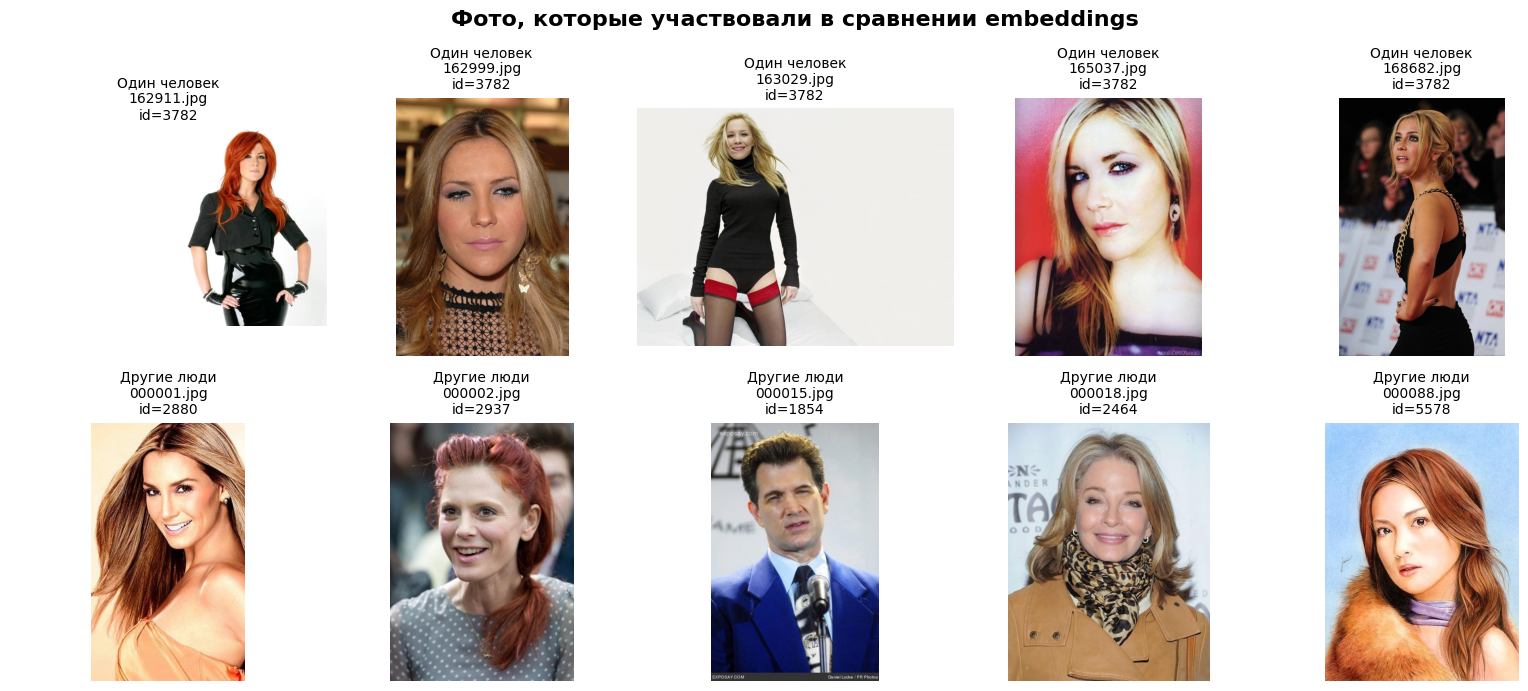

In [ ]:
plot_df = pd.concat(
    [
        same_df.assign(group="Один человек"),
        different_df.assign(group="Другие люди"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for ax, (_, row) in zip(axes, plot_df.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(img)
    ax.axis("off")

    title = f"{row['group']}\n{row['image_id']}\nid={row['identity_id']}"
    ax.set_title(title, fontsize=10)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(4)
        spine.set_edgecolor(border_color)

plt.suptitle(
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()
plt.show()